## I. Data preparation

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.neural_network import MLPClassifier

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

I0000 00:00:1775190120.693717    2752 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1775190120.701001    2752 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1775190121.478233    2752 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1775190123.498633    2752 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

### Get data

In [25]:
df_train = pd.read_csv('data/bank_data_train.csv')
df_test = pd.read_csv('data/bank_data_test.csv')

In [26]:
df_train.shape

(355190, 116)

### Percent of missing data

In [27]:
missing_percent = ((df_train.isnull().sum() / len(df_train)) * 100)
missing_percent = missing_percent[missing_percent > 0].sort_values(ascending=True)
missing_percent

AMOUNT_RUB_CLO_PRC         10.789437
AMOUNT_RUB_SUP_PRC         10.789437
TRANS_COUNT_SUP_PRC        10.789437
AMOUNT_RUB_NAS_PRC         10.789437
TRANS_COUNT_NAS_PRC        10.789437
                             ...    
MAX_PCLOSE_DATE            99.470424
AVG_PCT_MONTH_TO_PCLOSE    99.541654
LDEAL_YQZ_CHRG             99.650610
LDEAL_YQZ_COM              99.650891
CLNT_SALARY_VALUE          99.799544
Length: 81, dtype: float64

In [28]:
data_to_del = missing_percent[missing_percent>20]
data_to_del = data_to_del.index.to_list()
data_to_del

['SUM_TRAN_ATM_TENDENCY3M',
 'CNT_TRAN_ATM_TENDENCY3M',
 'CLNT_JOB_POSITION',
 'CNT_TRAN_ATM_TENDENCY1M',
 'SUM_TRAN_ATM_TENDENCY1M',
 'SUM_TRAN_SUP_TENDENCY3M',
 'CNT_TRAN_SUP_TENDENCY3M',
 'SUM_TRAN_SUP_TENDENCY1M',
 'CNT_TRAN_SUP_TENDENCY1M',
 'PRC_ACCEPTS_A_MTP',
 'PRC_ACCEPTS_MTP',
 'PRC_ACCEPTS_A_TK',
 'CNT_ACCEPTS_TK',
 'CNT_ACCEPTS_MTP',
 'PRC_ACCEPTS_A_ATM',
 'PRC_ACCEPTS_TK',
 'PRC_ACCEPTS_A_AMOBILE',
 'PRC_ACCEPTS_A_POS',
 'PRC_ACCEPTS_A_EMAIL_LINK',
 'CNT_TRAN_MED_TENDENCY3M',
 'SUM_TRAN_MED_TENDENCY3M',
 'CNT_TRAN_CLO_TENDENCY3M',
 'SUM_TRAN_CLO_TENDENCY3M',
 'CNT_TRAN_AUT_TENDENCY3M',
 'SUM_TRAN_AUT_TENDENCY3M',
 'LDEAL_ACT_DAYS_PCT_AAVG',
 'DEAL_YWZ_IR_MIN',
 'LDEAL_USED_AMT_AVG_YWZ',
 'DEAL_YWZ_IR_MAX',
 'LDEAL_DELINQ_PER_MAXYWZ',
 'MED_DEBT_PRC_YWZ',
 'LDEAL_ACT_DAYS_PCT_TR',
 'LDEAL_ACT_DAYS_ACC_PCT_AVG',
 'LDEAL_ACT_DAYS_PCT_TR3',
 'LDEAL_ACT_DAYS_PCT_TR4',
 'LDEAL_ACT_DAYS_PCT_CURR',
 'SUM_TRAN_AUT_TENDENCY1M',
 'CNT_TRAN_AUT_TENDENCY1M',
 'DEAL_GRACE_DAYS_ACC_S1X1'

### Delete useless fields

In [29]:
df_clean = df_train.drop(columns=data_to_del)
df_clean

,ID,CR_PROD_CNT_IL,AMOUNT_RUB_CLO_PRC,TURNOVER_DYNAMIC_IL_1M,AMOUNT_RUB_SUP_PRC,REST_DYNAMIC_FDEP_1M,REST_DYNAMIC_SAVE_3M,CR_PROD_CNT_VCU,REST_AVG_CUR,AMOUNT_RUB_NAS_PRC,...,CLNT_SETUP_TENOR,TURNOVER_DYNAMIC_PAYM_3M,TURNOVER_DYNAMIC_PAYM_1M,TRANS_AMOUNT_TENDENCY3M,TRANS_CNT_TENDENCY3M,REST_DYNAMIC_CC_1M,TURNOVER_DYNAMIC_CC_1M,REST_DYNAMIC_CC_3M,TURNOVER_DYNAMIC_CC_3M,TARGET
0,146841,0,0.000000,0.0,0.000000,0.0,0.541683,0,156067.339767,0.000000,...,1.593023,0.0,0.0,0.483032,0.406780,0.0,0.0,0.0,0.0,0
1,146842,0,0.041033,0.0,0.244678,0.0,0.000000,0,4278.845817,0.000000,...,1.587647,0.0,0.0,0.394340,0.545455,0.0,0.0,0.0,0.0,0
2,146843,0,0.006915,0.0,0.000000,0.0,0.000000,0,112837.062817,0.000000,...,1.587647,0.0,0.0,0.399342,0.297297,0.0,0.0,0.0,0.0,0
3,146844,0,0.000000,0.0,0.000000,0.0,0.005874,0,42902.902883,0.000000,...,1.583333,0.0,0.0,NaN,NaN,0.0,0.0,0.0,0.0,0
4,146845,0,0.000000,0.0,0.000000,0.0,0.000000,0,71906.476533,0.000000,...,1.583333,0.0,0.0,0.611610,0.620690,0.0,0.0,0.0,0.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
355185,590822,0,0.000000,0.0,0.000000,0.0,0.000000,0,9697.620867,0.000000,...,8.963872,0.0,0.0,0.659039,0.785714,0.0,0.0,0.0,0.0,0
355186,590823,0,0.000000,0.0,0.000000,0.0,0.000000,0,428380.024733,0.262714,...,8.963872,0.0,0.0,0.652612,0.500000,0.0,0.0,0.0,0.0,0
355187,590825,0,0.041298,0.0,0.095187,0.0,0.000000,0,224884.436700,0.031179,...,8.966560,0.0,0.0,0.448386,0.459530,0.0,0.0,0.0,0.0,0
355188,590826,0,0.000000,0.0,0.000000,0.0,0.000000,0,12080.001833,0.282573,...,8.966560,0.0,0.0,1.000000,1.000000,0.0,0.0,0.0,0.0,0


In [30]:
data_to_add = (df_clean.isna().sum() / len(df_clean) * 100).sort_values(ascending=False)
data_to_add = data_to_add[data_to_add > 0].index.to_list()
data_to_add

['TRANS_CNT_TENDENCY3M',
 'TRANS_AMOUNT_TENDENCY3M',
 'AMOUNT_RUB_CLO_PRC',
 'TRANS_COUNT_SUP_PRC',
 'AMOUNT_RUB_NAS_PRC',
 'TRANS_COUNT_ATM_PRC',
 'TRANS_COUNT_NAS_PRC',
 'AMOUNT_RUB_SUP_PRC',
 'AMOUNT_RUB_ATM_PRC']

### Fill fields with low percentage of missing args

In [31]:
for name in data_to_add:
    df_filled = df_clean.fillna(df_clean[name].median())

In [32]:
(df_filled.isna().sum() / len(df_filled) * 100).sort_values(ascending=False)

ID                          0.0
CR_PROD_CNT_IL              0.0
AMOUNT_RUB_CLO_PRC          0.0
TURNOVER_DYNAMIC_IL_1M      0.0
AMOUNT_RUB_SUP_PRC          0.0
REST_DYNAMIC_FDEP_1M        0.0
REST_DYNAMIC_SAVE_3M        0.0
CR_PROD_CNT_VCU             0.0
REST_AVG_CUR                0.0
AMOUNT_RUB_NAS_PRC          0.0
TRANS_COUNT_SUP_PRC         0.0
TRANS_COUNT_NAS_PRC         0.0
CR_PROD_CNT_TOVR            0.0
CR_PROD_CNT_PIL             0.0
TURNOVER_CC                 0.0
TRANS_COUNT_ATM_PRC         0.0
AMOUNT_RUB_ATM_PRC          0.0
TURNOVER_PAYM               0.0
AGE                         0.0
CR_PROD_CNT_CC              0.0
REST_DYNAMIC_FDEP_3M        0.0
REST_DYNAMIC_IL_1M          0.0
CR_PROD_CNT_CCFP            0.0
REST_DYNAMIC_CUR_1M         0.0
REST_AVG_PAYM               0.0
LDEAL_GRACE_DAYS_PCT_MED    0.0
REST_DYNAMIC_CUR_3M         0.0
TURNOVER_DYNAMIC_CUR_1M     0.0
REST_DYNAMIC_PAYM_3M        0.0
REST_DYNAMIC_IL_3M          0.0
TURNOVER_DYNAMIC_IL_3M      0.0
REST_DYN

In [33]:
df_filled.duplicated().sum()

np.int64(0)

In [34]:
df_filled = df_filled.drop_duplicates()

### Visualization fileds

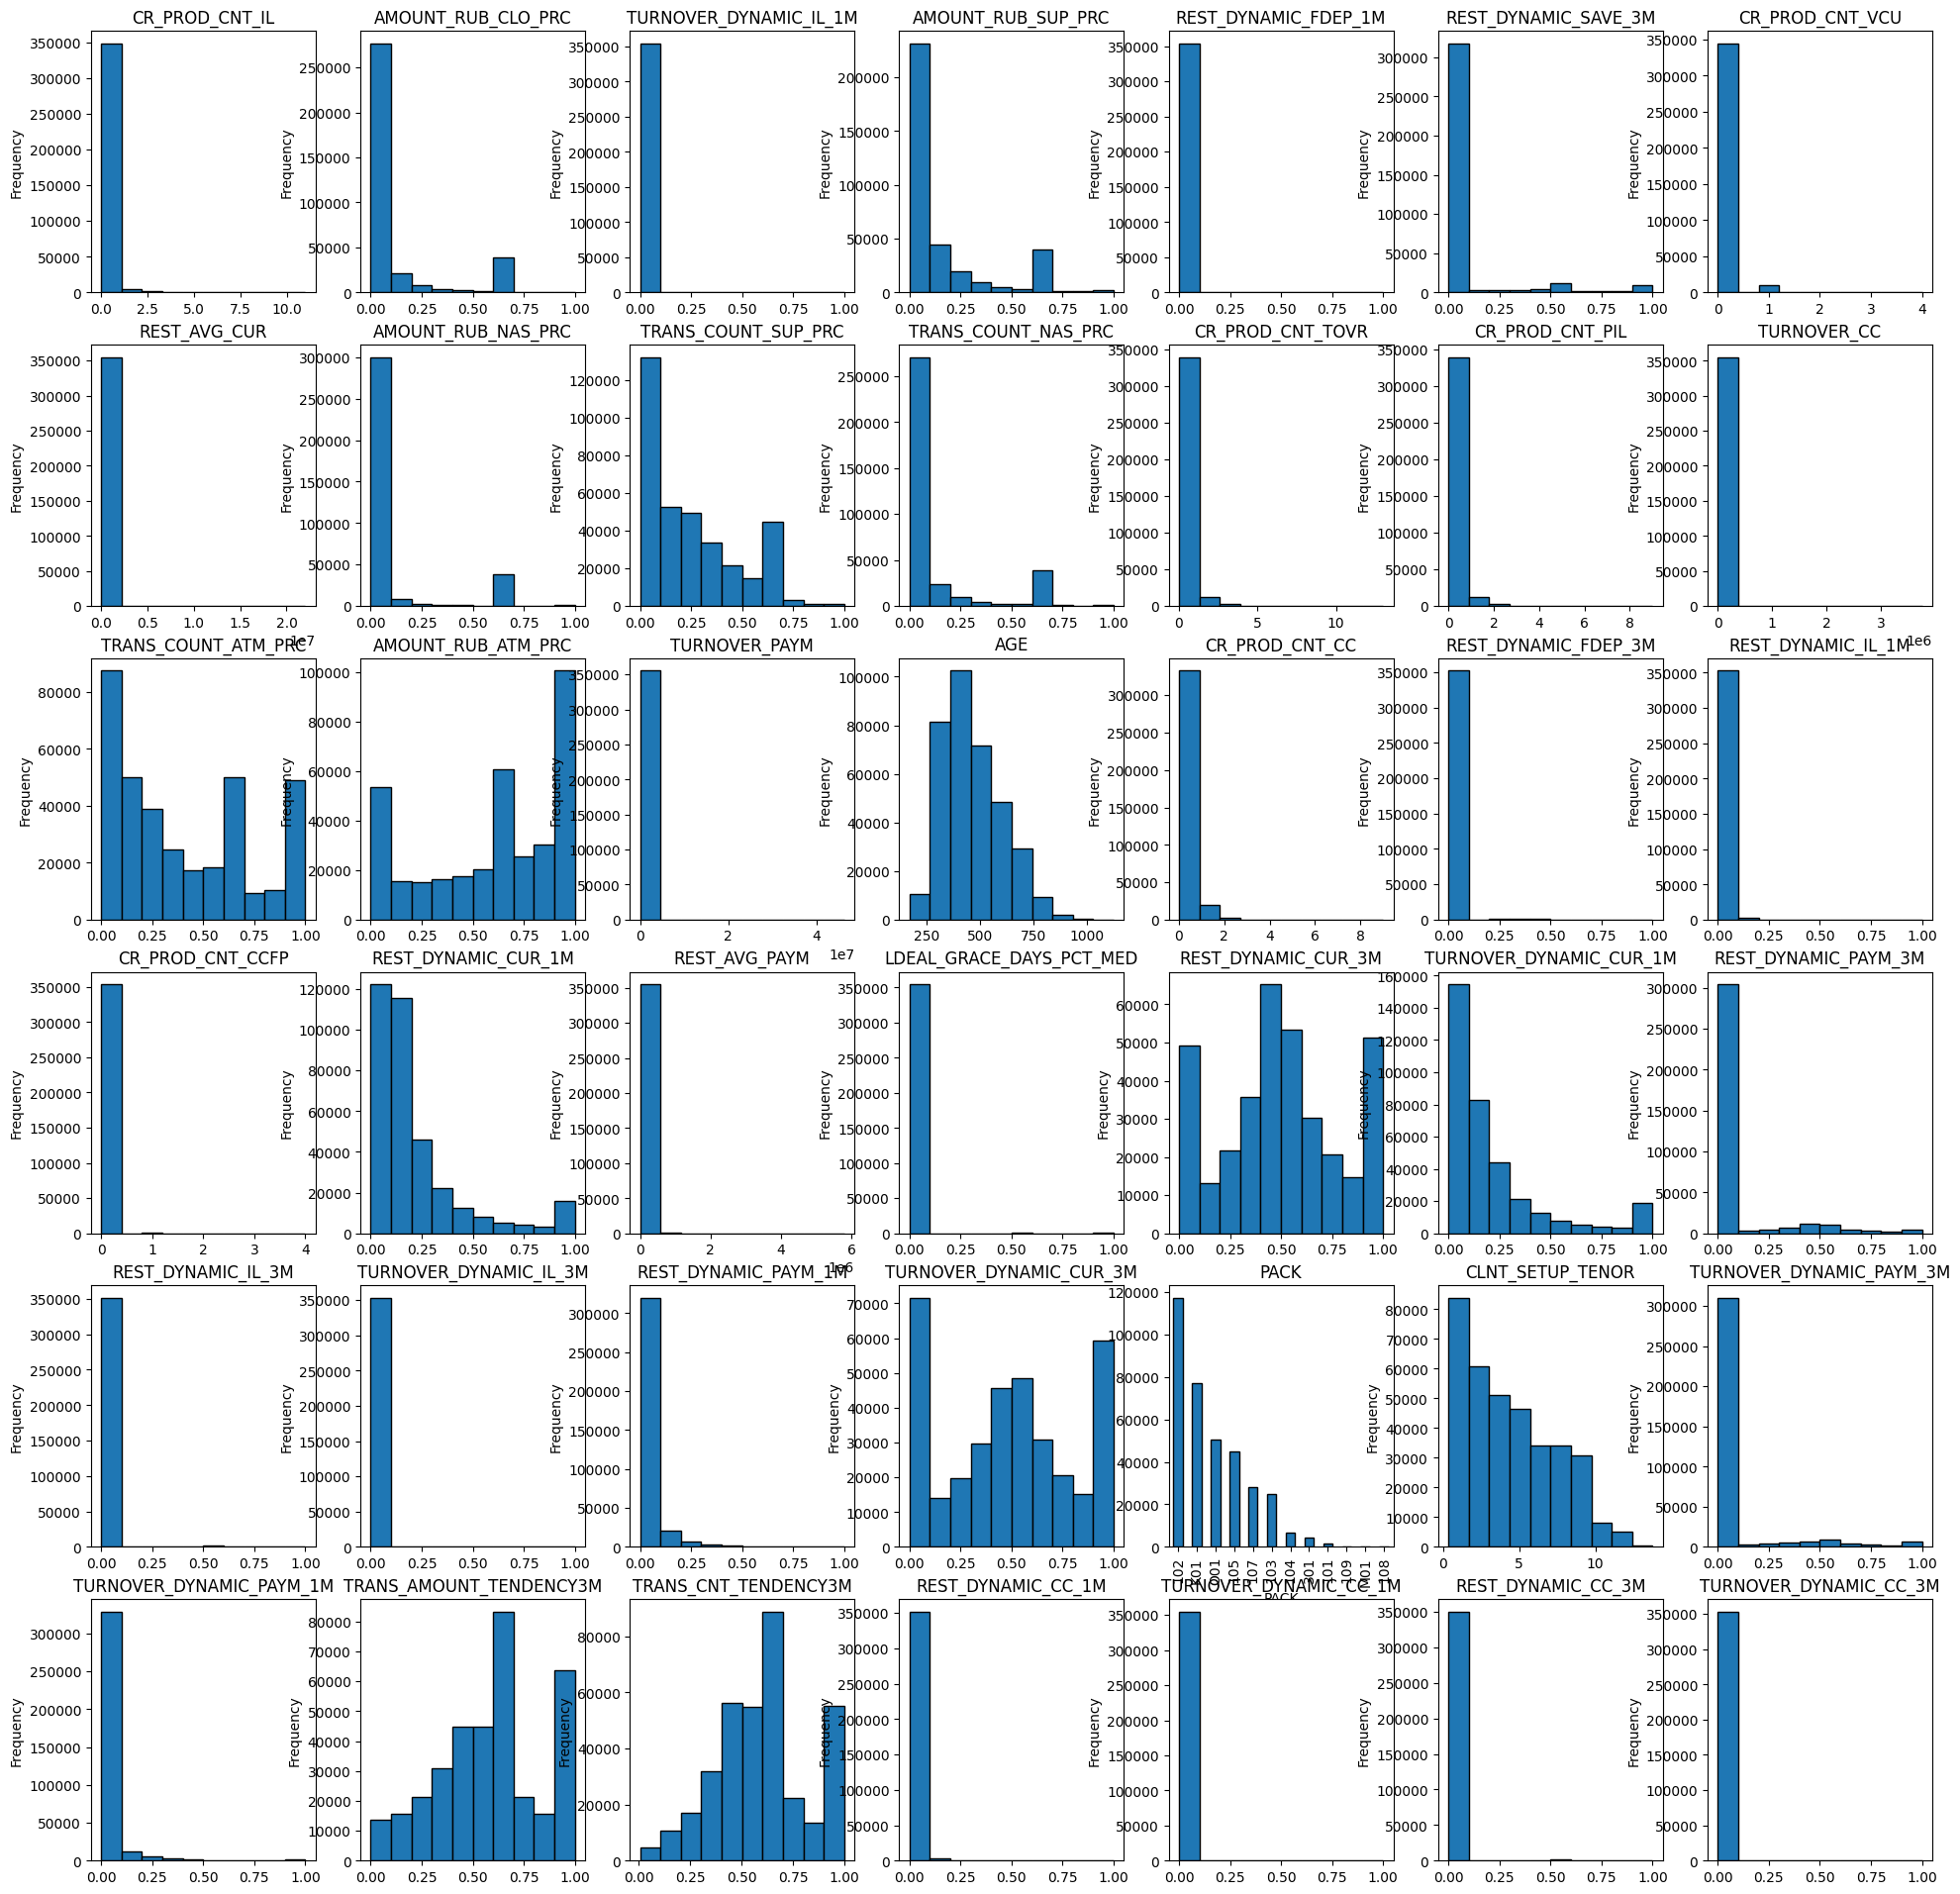

In [17]:
fig, axes = plt.subplots(6, 7, figsize=(24, 24))
for ax, col in zip(axes.flatten(), df_filled.drop(columns='ID').columns):
    ax.set_title(col)
    if col == 'PACK':
        df_filled[col].value_counts().plot(kind="bar", ec="black", ax=ax)
    else:
        df_filled[col].plot(kind="hist", ec="black", ax=ax)

In [35]:
df_filled['TARGET'].value_counts()

TARGET
0    326265
1     28925
Name: count, dtype: int64

## II. Learning

In [36]:
X_train, X_test, y_train, y_test = train_test_split(df_filled.drop(['TARGET'], axis=1), df_filled['TARGET'], test_size=0.2, stratify=df_filled['TARGET'])

In [37]:
X_train

,ID,CR_PROD_CNT_IL,AMOUNT_RUB_CLO_PRC,TURNOVER_DYNAMIC_IL_1M,AMOUNT_RUB_SUP_PRC,REST_DYNAMIC_FDEP_1M,REST_DYNAMIC_SAVE_3M,CR_PROD_CNT_VCU,REST_AVG_CUR,AMOUNT_RUB_NAS_PRC,...,PACK,CLNT_SETUP_TENOR,TURNOVER_DYNAMIC_PAYM_3M,TURNOVER_DYNAMIC_PAYM_1M,TRANS_AMOUNT_TENDENCY3M,TRANS_CNT_TENDENCY3M,REST_DYNAMIC_CC_1M,TURNOVER_DYNAMIC_CC_1M,REST_DYNAMIC_CC_3M,TURNOVER_DYNAMIC_CC_3M
207293,405752,0,0.000000,0.0,0.065838,0.0,0.0,0,4898.859733,0.000000,...,103,3.848391,0.0,0.0,0.179717,0.392157,0.0,0.0,0.0,0.0
355086,590696,0,0.017609,0.0,0.266025,0.0,0.0,0,344619.656917,0.000000,...,103,3.969248,0.0,0.0,0.225458,0.675676,0.0,0.0,0.0,0.0
17339,168565,0,0.000000,0.0,0.000000,0.0,0.0,0,10054.721550,0.204940,...,102,5.383345,0.0,0.0,0.322698,0.263158,0.0,0.0,0.0,0.0
267677,481309,0,0.003657,0.0,0.217486,0.0,0.0,0,24888.030950,0.002787,...,107,1.859033,0.0,0.0,0.498023,0.458015,0.0,0.0,0.0,0.0
212631,412433,1,0.002669,0.0,0.000000,0.0,0.0,1,71126.258700,0.000000,...,102,8.004305,0.0,0.0,0.057052,0.291667,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299962,521767,1,0.689935,0.0,0.689935,0.0,0.0,0,13910.570000,0.689935,...,102,6.267635,0.0,0.0,0.689935,0.689935,0.0,0.0,0.0,0.0
180002,371771,0,0.000000,0.0,0.042727,0.0,1.0,0,900.323283,0.000000,...,O01,1.136026,0.0,0.0,1.000000,1.000000,0.0,0.0,0.0,0.0
196318,392064,0,0.000000,0.0,0.074762,0.0,0.0,0,2177.541383,0.000000,...,102,0.886026,0.0,0.0,0.378791,0.755102,0.0,0.0,0.0,0.0
291018,510631,0,0.014358,0.0,0.088873,0.0,0.0,0,11977.168533,0.000000,...,O01,3.756883,0.0,0.0,0.449207,0.558282,0.0,0.0,0.0,0.0


In [42]:
categorical_features = ['PACK']

X_train_cat = X_train[categorical_features]
X_train_num = X_train.drop(columns=categorical_features + ['ID'])

X_test_cat = X_test[categorical_features]
X_test_num = X_test.drop(columns=categorical_features + ['ID'])

encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
encoded = encoder.fit(X_train_cat)

X_train_encoded = pd.DataFrame(encoder.transform(X_train_cat), columns=encoded.get_feature_names_out(), index=X_train.index)
X_test_encoded = pd.DataFrame(encoder.transform(X_test_cat), columns=encoded.get_feature_names_out(), index=X_test.index)



In [43]:
scl = StandardScaler()
scl.fit(X_train_num)

X_train_scl = scl.transform(X_train_num)
X_test_scl = scl.transform(X_test_num)

X_train_scl = pd.DataFrame(X_train_scl, columns=X_train_num.columns, index=X_train.index)

X_test_scl = pd.DataFrame(X_test_scl, columns=X_test_num.columns,index=X_test.index)

In [44]:
X_train = pd.concat([X_train_scl, X_train_encoded], axis=1)
X_test = pd.concat([X_test_scl, X_test_encoded], axis=1)

In [45]:
X_train

,CR_PROD_CNT_IL,AMOUNT_RUB_CLO_PRC,TURNOVER_DYNAMIC_IL_1M,AMOUNT_RUB_SUP_PRC,REST_DYNAMIC_FDEP_1M,REST_DYNAMIC_SAVE_3M,CR_PROD_CNT_VCU,REST_AVG_CUR,AMOUNT_RUB_NAS_PRC,TRANS_COUNT_SUP_PRC,...,PACK_103,PACK_104,PACK_105,PACK_107,PACK_108,PACK_109,PACK_301,PACK_K01,PACK_M01,PACK_O01
207293,-0.244092,-0.505344,-0.044561,-0.366388,-0.051872,-0.311971,-0.169507,-0.324562,-0.428067,0.123909,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
355086,-0.244092,-0.427066,-0.044561,0.501580,-0.051872,-0.311971,-0.169507,1.473214,-0.428067,2.011787,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
17339,-0.244092,-0.505344,-0.044561,-0.651845,-0.051872,-0.311971,-0.169507,-0.297278,0.489410,-1.014532,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
267677,-0.244092,-0.489090,-0.044561,0.291125,-0.051872,-0.311971,-0.169507,-0.218781,-0.415589,1.027399,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0
212631,2.069038,-0.493479,-0.044561,-0.651845,-0.051872,-0.311971,5.280348,0.025908,-0.428067,-1.014532,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
299962,2.069038,2.561630,-0.044561,2.339552,-0.051872,-0.311971,-0.169507,-0.276873,2.660641,1.846750,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
180002,-0.244092,-0.505344,-0.044561,-0.466589,-0.051872,4.619101,-0.169507,-0.345722,-0.428067,0.229621,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
196318,-0.244092,-0.505344,-0.044561,-0.327694,-0.051872,-0.311971,-0.169507,-0.338963,-0.428067,1.439920,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
291018,-0.244092,-0.441520,-0.044561,-0.266511,-0.051872,-0.311971,-0.169507,-0.287105,-0.428067,0.003180,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


## Naive Classifier

In [19]:
y_pred = y_test.apply(lambda x: 0)
naive_accuracy = accuracy_score(y_test, y_pred)
print(f"Naive Classifier Accuracy: {naive_accuracy:.3f}")

Naive Classifier Accuracy: 0.919


In [20]:
naive_auc = roc_auc_score(y_test, y_pred)
print(f"Naive Classifier AUC: {naive_auc}")

Naive Classifier AUC: 0.5


## Random Forest

In [27]:
def run_grid(model, param_grid, X_train, y_train, X_test, y_test, cv=5):
    grid = GridSearchCV(
        estimator=model,
        param_grid=param_grid,
        cv=cv,
        scoring='accuracy',
        verbose=1
    )
    grid.fit(X_train, y_train)
    
    print(grid.best_params_)
    print(grid.best_score_)
    
    return grid.best_estimator_  

In [21]:
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [20, 50],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

print("\n=== Random Forest ===")
#rf = run_grid(
#    RandomForestClassifier(random_state=21),
#    rf_params,
#    X_train, y_train, X_test, y_test,
#    cv=2
#)


=== Random Forest ===


In [22]:
rf = RandomForestClassifier(max_depth = 50, min_samples_leaf = 1, min_samples_split = 5, n_estimators = 200)

In [23]:
rf.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,50
,min_samples_split,5
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [46]:
rf_auc = roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1])
print(f"Random Forest Classifier AUC: {rf_auc:.3f}")

Random Forest Classifier AUC: 0.967


In [47]:
rf_accuracy = accuracy_score(y_test, y_pred)
print(f"Random Forest Classifier accuracy: {rf_accuracy:.3f}")

Random Forest Classifier accuracy: 0.919


## MLP Classifier

In [48]:
mlp_params = {'alpha': 0.1, 'solver': 'sgd','learning_rate_init': 0.01, 'max_iter': 1000,'hidden_layer_sizes': (100,16), 'verbose': 1}
mlp = MLPClassifier(**mlp_params)
mlp.fit(X_train, y_train)

Iteration 1, loss = 0.28817573
Iteration 2, loss = 0.27075020
Iteration 3, loss = 0.26452560
Iteration 4, loss = 0.25986205
Iteration 5, loss = 0.25600168
Iteration 6, loss = 0.25281550
Iteration 7, loss = 0.25034442
Iteration 8, loss = 0.24850223
Iteration 9, loss = 0.24710029
Iteration 10, loss = 0.24577378
Iteration 11, loss = 0.24452696
Iteration 12, loss = 0.24374015
Iteration 13, loss = 0.24304463
Iteration 14, loss = 0.24225853
Iteration 15, loss = 0.24191264
Iteration 16, loss = 0.24111680
Iteration 17, loss = 0.24083866
Iteration 18, loss = 0.24036023
Iteration 19, loss = 0.24001831
Iteration 20, loss = 0.23979267
Iteration 21, loss = 0.23942312
Iteration 22, loss = 0.23929642
Iteration 23, loss = 0.23910225
Iteration 24, loss = 0.23913956
Iteration 25, loss = 0.23850299
Iteration 26, loss = 0.23900869
Iteration 27, loss = 0.23859167
Iteration 28, loss = 0.23836960
Iteration 29, loss = 0.23847868
Iteration 30, loss = 0.23821202
Iteration 31, loss = 0.23822651
Iteration 32, los

,hidden_layer_sizes,"(100, ...)"
,activation,'relu'
,solver,'sgd'
,alpha,0.1
,batch_size,'auto'
,learning_rate,'constant'
,learning_rate_init,0.01
,power_t,0.5
,max_iter,1000
,shuffle,True
,random_state,None


In [49]:
mlp_sklearn_auc = roc_auc_score(y_test, mlp.predict_proba(X_test)[:, 1])
print(f"MLP sklearn AUC: {mlp_sklearn_auc:.3f}")

MLP sklearn AUC: 0.820


In [50]:
mlp_sklearn_accuracy = mlp.score(X_test, y_test)
print(f"MLP sklearn accuracy: {mlp_sklearn_accuracy:.3f}")

MLP sklearn accuracy: 0.919


## Tensorflow 

In [51]:
X_train_np = X_train.values.astype(np.float32)
X_test_np = X_test.values.astype(np.float32)
y_train_np = y_train.values.reshape(-1, 1).astype(np.float32)
y_test_np = y_test.values.reshape(-1, 1).astype(np.float32)

X_train_tf = tf.constant(X_train_np, dtype=tf.float32)
y_train_tf = tf.constant(y_train_np, dtype=tf.float32)
X_test_tf = tf.constant(X_test_np, dtype=tf.float32)
y_test_tf = tf.constant(y_test_np, dtype=tf.float32)

W1 = tf.Variable(tf.random.normal([X_train_np.shape[1], 32], stddev=0.1))
b1 = tf.Variable(tf.zeros([32]))
W2 = tf.Variable(tf.random.normal([32, 16], stddev=0.1))
b2 = tf.Variable(tf.zeros([16]))
W3 = tf.Variable(tf.random.normal([16, 1], stddev=0.1))
b3 = tf.Variable(tf.zeros([1]))

def forward(X):
    h1 = tf.nn.relu(tf.matmul(X, W1) + b1)
    h2 = tf.nn.relu(tf.matmul(h1, W2) + b2)
    output = tf.nn.sigmoid(tf.matmul(h2, W3) + b3)
    return output

def loss_fn(y_true, y_pred):
    y_pred = tf.clip_by_value(y_pred, 1e-15, 1 - 1e-15)
    return -tf.reduce_mean(y_true * tf.math.log(y_pred) + (1 - y_true) * tf.math.log(1 - y_pred))

optimizer = tf.optimizers.Adam(learning_rate=0.001)

for epoch in range(2000):
    with tf.GradientTape() as tape:
        y_pred = forward(X_train_tf)
        loss = loss_fn(y_train_tf, y_pred)
    
    gradients = tape.gradient(loss, [W1, b1, W2, b2, W3, b3])
    optimizer.apply_gradients(zip(gradients, [W1, b1, W2, b2, W3, b3]))
    
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}, Loss: {loss.numpy():.6f}")

y_pred_proba = forward(X_test_tf).numpy().flatten()
y_pred = (y_pred_proba > 0.5).astype(int)

# Оценка
tf_accuracy = accuracy_score(y_test_np, y_pred)
tf_auc = roc_auc_score(y_test_np, y_pred_proba)

print(f"\nAccuracy: {tf_accuracy:.4f}")
print(f"AUC-ROC: {tf_auc:.4f}")

E0000 00:00:1775190748.840966    2752 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1775190748.844473    5678 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1775190748.877497    2752 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Epoch 100, Loss: 0.276968
Epoch 200, Loss: 0.264413
Epoch 300, Loss: 0.259830
Epoch 400, Loss: 0.255909
Epoch 500, Loss: 0.252673
Epoch 600, Loss: 0.249478
Epoch 700, Loss: 0.246227
Epoch 800, Loss: 0.243550
Epoch 900, Loss: 0.241032
Epoch 1000, Loss: 0.238160
Epoch 1100, Loss: 0.235188
Epoch 1200, Loss: 0.232646
Epoch 1300, Loss: 0.230528
Epoch 1400, Loss: 0.228744
Epoch 1500, Loss: 0.227329
Epoch 1600, Loss: 0.226188
Epoch 1700, Loss: 0.225200
Epoch 1800, Loss: 0.224319
Epoch 1900, Loss: 0.223471
Epoch 2000, Loss: 0.222685

Accuracy: 0.9187
AUC-ROC: 0.8249


## Tensorflow Keras

In [52]:
def create_model():
    model = Sequential()
    model.add(Dense(32, input_dim=X_train.shape[1], activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(16, activation='relu'))
    model.add(Dropout(0.5))
    model.add(Dense(1, activation='sigmoid'))

    model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=0.001), metrics=['accuracy'])
    return model

In [53]:
keras_params = {'epochs': 100, 'batch_size': 32, 'verbose': 1}

In [54]:
model = create_model()
model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=1)

Epoch 1/10
8880/8880 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step - accuracy: 0.9178 - loss: 0.2794
Epoch 2/10
8880/8880 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step - accuracy: 0.9185 - loss: 0.2603
Epoch 3/10
8880/8880 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step - accuracy: 0.9185 - loss: 0.2563
Epoch 4/10
8880/8880 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step - accuracy: 0.9185 - loss: 0.2538
Epoch 5/10
8880/8880 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step - accuracy: 0.9185 - loss: 0.2522
Epoch 6/10
8880/8880 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step - accuracy: 0.9184 - loss: 0.2514
Epoch 7/10
8880/8880 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step - accuracy: 0.9184 - loss: 0.2504
Epoch 8/10
8880/8880 ━━━━━━━━━━━━━━━━━━━━ 11s 1ms/step - accuracy: 0.9184 - loss: 0.2497
Epoch 9/10
8880/8880 ━━━━━━━━━━━━━━━━━━━━ 12s 1ms/step - accuracy: 0.9184 - loss: 0.2492
Epoch 10/10
8880/8880 ━━━━━━━━━━━━━━━━━━━━ 13s 1ms/step - accuracy: 0.9185 - loss: 0.2486


In [55]:
_, mlp_keras_accuracy = model.evaluate(X_test, y_test, verbose=0)
print('Accuracy: %.3f' % mlp_keras_accuracy)

y_pred_prob = model.predict(X_test)
mlp_keras_auc = roc_auc_score(y_test, y_pred_prob)
print('AUC: %.3f' % mlp_keras_auc)

Accuracy: 0.919
2220/2220 ━━━━━━━━━━━━━━━━━━━━ 1s 266us/step
AUC: 0.806


## MLP with NumPy

In [56]:
class Sigmoid:
    def __call__(self, x):
        x = np.clip(x, -500, 500)
        return 1 / (1 + np.exp(-x))
    
    def gradient(self, x):
        s = self.__call__(x)
        return s * (1 - s)

class ReLU:
    def __call__(self, x):
        return np.maximum(0, x)
    
    def gradient(self, x):
        return (x > 0).astype(float)

In [57]:
class BinaryCrossEntropy:
    def loss(self, y_true, y_pred):
        y_pred = np.clip(y_pred, 1e-15, 1 - 1e-15)
        return -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
    
    def accuracy(self, y_true, y_pred, threshold=0.5):
        return accuracy_score(y_true.flatten(), (y_pred > threshold).flatten())

In [58]:
class NeuralNetwork:
    def __init__(self, hidden_layers=[64, 32], learning_rate=0.002, n_iterations=800, batch_size=64):
        self.hidden_layers = hidden_layers
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.batch_size = batch_size
        self.activation = ReLU()
        self.loss_fn = BinaryCrossEntropy()
        self.weights = []
        self.biases = []
        self.train_losses = []
        
    def _initialize_weights(self, n_features):
        layer_sizes = [n_features] + self.hidden_layers + [1]
        for i in range(len(layer_sizes) - 1):
            limit = np.sqrt(6 / (layer_sizes[i] + layer_sizes[i + 1]))
            self.weights.append(np.random.uniform(-limit, limit, (layer_sizes[i], layer_sizes[i + 1])))
            self.biases.append(np.zeros((1, layer_sizes[i + 1])))
    
    def _forward(self, X, training=True):
        caches = []
        current_input = X
        
        for i in range(len(self.weights) - 1):
            z = np.dot(current_input, self.weights[i]) + self.biases[i]
            a = self.activation(z)
            caches.append((z, a))
            current_input = a
        
        z_out = np.dot(current_input, self.weights[-1]) + self.biases[-1]
        a_out = Sigmoid()(z_out)
        caches.append((z_out, a_out))
        
        return a_out, caches
    
    def _backward(self, X, y_true, y_pred, caches):
        n_samples = X.shape[0]
        gradients_w = []
        gradients_b = []
        
        dz = y_pred - y_true
        prev_activation = caches[-2][1] if len(caches) > 1 else X
        
        gradients_w.insert(0, np.dot(prev_activation.T, dz) / n_samples)
        gradients_b.insert(0, np.sum(dz, axis=0, keepdims=True) / n_samples)
        
        current_grad = dz
        for i in range(len(self.weights) - 2, -1, -1):
            current_grad = np.dot(current_grad, self.weights[i + 1].T)
            current_grad *= self.activation.gradient(caches[i][0])
            
            prev_activation = caches[i-1][1] if i > 0 else X
            gradients_w.insert(0, np.dot(prev_activation.T, current_grad) / n_samples)
            gradients_b.insert(0, np.sum(current_grad, axis=0, keepdims=True) / n_samples)
        
        return gradients_w, gradients_b
    
    def fit(self, X_train, y_train, X_val=None, y_val=None, verbose=True):
        self._initialize_weights(X_train.shape[1])
        n_samples = X_train.shape[0]
        
        for epoch in range(self.n_iterations):
            indices = np.random.permutation(n_samples)
            X_shuffled = X_train[indices]
            y_shuffled = y_train[indices]
            epoch_loss = 0
            
            for i in range(0, n_samples, self.batch_size):
                X_batch = X_shuffled[i:i+self.batch_size]
                y_batch = y_shuffled[i:i+self.batch_size]
                
                y_pred, caches = self._forward(X_batch)
                epoch_loss += self.loss_fn.loss(y_batch, y_pred) * len(X_batch)
                
                gradients_w, gradients_b = self._backward(X_batch, y_batch, y_pred, caches)
                
                for j in range(len(self.weights)):
                    self.weights[j] -= self.learning_rate * gradients_w[j]
                    self.biases[j] -= self.learning_rate * gradients_b[j]
            
            avg_loss = epoch_loss / n_samples
            self.train_losses.append(avg_loss)
            
            if verbose and (epoch + 1) % 100 == 0:
                train_acc = self.loss_fn.accuracy(y_train, self.predict(X_train))
                print(f"Epoch {epoch+1}/{self.n_iterations}, Loss: {avg_loss:.6f}, Train Acc: {train_acc:.4f}")
    
    def predict(self, X):
        predictions, _ = self._forward(X, training=False)
        return predictions
    
    def predict_classes(self, X, threshold=0.5):
        return (self.predict(X) > threshold).astype(int)

In [59]:
X_train_np = X_train.values.astype(np.float32)
X_test_np = X_test.values.astype(np.float32)
y_train_np = y_train.values.reshape(-1, 1).astype(np.float32)
y_test_np = y_test.values.reshape(-1, 1).astype(np.float32)

In [60]:
X_train_np, X_val_np, y_train_np, y_val_np = train_test_split(
    X_train_np, y_train_np, test_size=0.2, random_state=42, stratify=y_train_np
)

In [61]:
nn = NeuralNetwork(
    hidden_layers=[64, 32],
    learning_rate=0.001,
    n_iterations=800,
    batch_size=64
)

In [62]:
nn.fit(X_train_np, y_train_np, X_val_np, y_val_np)

Epoch 100/800, Loss: 0.244910, Train Acc: 0.9188
Epoch 200/800, Loss: 0.236992, Train Acc: 0.9189
Epoch 300/800, Loss: 0.230696, Train Acc: 0.9193
Epoch 400/800, Loss: 0.226838, Train Acc: 0.9195
Epoch 500/800, Loss: 0.223768, Train Acc: 0.9195
Epoch 600/800, Loss: 0.221050, Train Acc: 0.9198
Epoch 700/800, Loss: 0.218990, Train Acc: 0.9199
Epoch 800/800, Loss: 0.217351, Train Acc: 0.9200


In [63]:
y_pred_proba = nn.predict(X_test_np)
y_pred = nn.predict_classes(X_test_np)

numpy_accuracy = accuracy_score(y_test_np, y_pred)
numpy_auc = roc_auc_score(y_test_np, y_pred_proba)

print(f"\n=== Результаты ===")
print(f"Accuracy: {numpy_accuracy:.4f}")
print(f"AUC-ROC: {numpy_auc:.4f}")


=== Результаты ===
Accuracy: 0.9183
AUC-ROC: 0.8233


In [64]:
df_test.head()

,ID,CR_PROD_CNT_IL,AMOUNT_RUB_CLO_PRC,PRC_ACCEPTS_A_EMAIL_LINK,APP_REGISTR_RGN_CODE,PRC_ACCEPTS_A_POS,PRC_ACCEPTS_A_TK,TURNOVER_DYNAMIC_IL_1M,CNT_TRAN_AUT_TENDENCY1M,SUM_TRAN_AUT_TENDENCY1M,...,REST_DYNAMIC_CC_3M,MED_DEBT_PRC_YWZ,LDEAL_ACT_DAYS_PCT_TR3,LDEAL_ACT_DAYS_PCT_AAVG,LDEAL_DELINQ_PER_MAXYWZ,TURNOVER_DYNAMIC_CC_3M,LDEAL_ACT_DAYS_PCT_TR,LDEAL_ACT_DAYS_PCT_TR4,LDEAL_ACT_DAYS_PCT_CURR,TARGET
0,400980,0,0.000000,NaN,NaN,NaN,NaN,0.0,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN
1,525062,0,0.059381,0.0,NaN,0.0,0.0,0.0,NaN,NaN,...,0.0,1.0,0.5,0.5,0.0,0.0,0.5,0.5,0.5,NaN
2,280316,0,0.070430,0.0,NaN,0.0,0.0,0.0,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN
3,496066,0,NaN,0.0,NaN,0.0,0.0,0.0,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN
4,375031,0,0.180961,0.0,77.0,0.0,0.0,0.0,NaN,NaN,...,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN


In [65]:
cols = df_clean.columns.tolist()
df_test_ready = df_test[cols]
X = df_test_ready.drop(['ID', 'TARGET'], axis=1) 

In [67]:
X_ohe = pd.DataFrame(encoder.transform(X[categorical_features]), columns=encoded.get_feature_names_out())
X = pd.concat([X.reset_index(), X_ohe.reset_index()], axis=1).drop(['index'], axis=1)
X.drop(categorical_features, axis=1, inplace=True)

In [68]:
X = pd.concat([pd.DataFrame(scl.transform(X.iloc[:,:-12]), columns=scl.get_feature_names_out()),
                    X.iloc[:,-12:]], axis=1)

In [69]:
X.fillna(0, inplace=True)

In [70]:
res = pd.DataFrame(mlp.predict(X), columns=['TARGET'])
res['ID'] = df_test['ID']

In [71]:
res.TARGET.value_counts()

TARGET
0    88701
1       97
Name: count, dtype: int64

In [73]:
res.to_csv('predictions.csv')

In [74]:
results_table = pd.DataFrame([
    {'Model': 'Naive Classifier', 'Accuracy': naive_accuracy, 'AUC': naive_auc},
    {'Model': 'Random Forest', 'Accuracy': rf_accuracy, 'AUC': rf_auc},
    {'Model': 'MLPClassifier', 'Accuracy': mlp_sklearn_auc, 'AUC': mlp_sklearn_accuracy},
    {'Model': 'Keras', 'Accuracy': mlp_keras_accuracy, 'AUC': mlp_keras_auc},
    {'Model': 'Pure TensorFlow', 'Accuracy': tf_accuracy, 'AUC': tf_auc},
    {'Model': 'NumPy NN', 'Accuracy': numpy_accuracy, 'AUC': numpy_auc},
])

results_table

,Model,Accuracy,AUC
0,Naive Classifier,0.918565,0.500000
1,Random Forest,0.918565,0.966561
2,MLPClassifier,0.820188,0.918776
3,Keras,0.918565,0.805567
4,Pure TensorFlow,0.918748,0.824880
5,NumPy NN,0.918339,0.823258
